In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
%matplotlib inline
import warnings
warnings.simplefilter('ignore')

In [2]:
# Making Dataset (linear)
X, y = skl.datasets.make_classification(
    n_samples=1000, n_features=2, n_clusters_per_class=1, n_redundant=0
)

<Axes: xlabel='0', ylabel='1'>

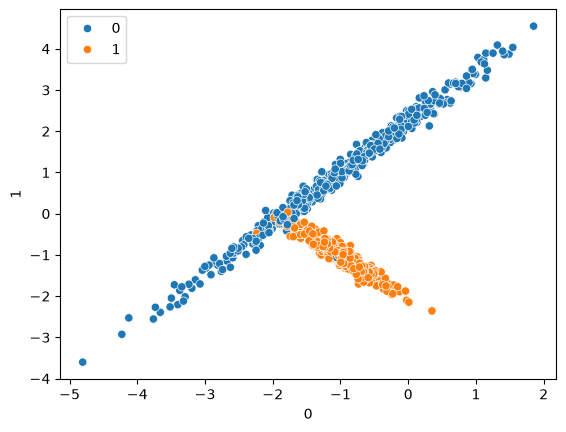

In [3]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)

In [4]:
# Train test split
X_train, X_test, y_train, y_test = skl.model_selection.train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [5]:
# Training by SVM
lin = skl.svm.SVC(kernel="linear")
lin.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
y_pred = lin.predict(X_test)

In [7]:
print(skl.metrics.confusion_matrix(y_test,y_pred))
print(skl.metrics.classification_report(y_test,y_pred))

[[132   0]
 [  5 113]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       132
           1       1.00      0.96      0.98       118

    accuracy                           0.98       250
   macro avg       0.98      0.98      0.98       250
weighted avg       0.98      0.98      0.98       250



In [8]:
# Making Dataset (overlapping)
X, y = skl.datasets.make_classification(
    n_samples=1000, n_features=2, n_clusters_per_class=2, n_redundant=0
)

<Axes: xlabel='0', ylabel='1'>

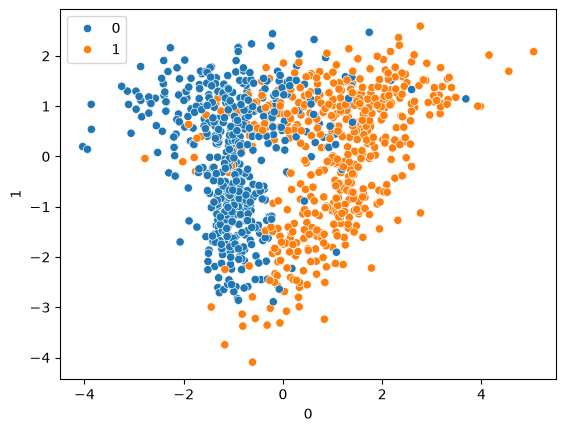

In [9]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)

### Using multiple kernels to check which one gives better accuracy

In [10]:
rbf = skl.svm.SVC(kernel='rbf')
rbf.fit(X_train,y_train)
y_pred = rbf.predict(X_test)
print(skl.metrics.confusion_matrix(y_test,y_pred))
print(skl.metrics.classification_report(y_test,y_pred))

[[132   0]
 [  5 113]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       132
           1       1.00      0.96      0.98       118

    accuracy                           0.98       250
   macro avg       0.98      0.98      0.98       250
weighted avg       0.98      0.98      0.98       250



In [11]:
sigmoid = skl.svm.SVC(kernel='sigmoid')
sigmoid.fit(X_train,y_train)
y_pred = sigmoid.predict(X_test)
print(skl.metrics.confusion_matrix(y_test,y_pred))
print(skl.metrics.classification_report(y_test,y_pred))

[[103  29]
 [  7 111]]
              precision    recall  f1-score   support

           0       0.94      0.78      0.85       132
           1       0.79      0.94      0.86       118

    accuracy                           0.86       250
   macro avg       0.86      0.86      0.86       250
weighted avg       0.87      0.86      0.86       250



In [12]:
poly = skl.svm.SVC(kernel='poly')
poly.fit(X_train,y_train)
y_pred = poly.predict(X_test)
print(skl.metrics.confusion_matrix(y_test,y_pred))
print(skl.metrics.classification_report(y_test,y_pred))

[[132   0]
 [  4 114]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       132
           1       1.00      0.97      0.98       118

    accuracy                           0.98       250
   macro avg       0.99      0.98      0.98       250
weighted avg       0.98      0.98      0.98       250



## Hyperparameter tuning

In [13]:
params_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "gamma": [0.1, 0.01, 0.001, 0.0001],
    "kernel": ["linear", "rbf", "sigmoid", "poly"],
}

In [14]:
# GridSearch CV
grid = skl.model_selection.GridSearchCV(estimator=skl.svm.SVC(), param_grid=params_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'gamma': [0.1, 0.01, ...], 'kernel': ['linear', 'rbf', ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information

In [15]:
grid.best_params_

{'C': 1000, 'gamma': 0.1, 'kernel': 'rbf'}

In [18]:
grid.best_score_

np.float64(0.9799999999999999)

In [16]:
y_pred = grid.predict(X_test)

In [17]:
print(skl.metrics.confusion_matrix(y_test,y_pred))
print(skl.metrics.classification_report(y_test,y_pred))

[[132   0]
 [  3 115]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       132
           1       1.00      0.97      0.99       118

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250

